In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import xarray as xr
import matplotlib.image as mpimg

In [2]:
# Load IB data
dfib = pd.read_csv("../PIKE_out/size_only/IBTrACS_TC_Size.csv",keep_default_na=False)
# Load basin/land mask file
basinmask1=xr.open_dataset('../basin_mask_05deg.nc').mask 
basinmask1=basinmask1.fillna(-1)

In [3]:
# SyCLoPS classified track files
files = {
    'mris': '../classified_track/SyCLoPS_track/SyCLoPS_classified_MRI-S.parquet',
    'mrih': '../classified_track/SyCLoPS_track/SyCLoPS_classified_MRI-H.parquet',
    'ipslhr': '../classified_track/SyCLoPS_track/SyCLoPS_classified_IPSL-HR.parquet',
    'ipslvhr': '../classified_track/SyCLoPS_track/SyCLoPS_classified_IPSL-VHR.parquet',
    'echrm1': '../classified_track/SyCLoPS_track/SyCLoPS_classified_ECMWF-HR-mem1.parquet',
    'eclrm1': '../classified_track/SyCLoPS_track/SyCLoPS_classified_ECMWF-LR-mem1.parquet',
    'era5deg1': '../classified_track/SyCLoPS_track/SyCLoPS_classified_ERA5deg1.parquet',
    'era5': '../classified_track/SyCLoPS_track/SyCLoPS_classified_ERA5.parquet',
    'hadgem': '../classified_track/SyCLoPS_track/SyCLoPS_classified_HadGEM-HR.parquet',
    'hadgem-coup': '../classified_track/SyCLoPS_track/SyCLoPS_classified_HadGEM-HR-COUP.parquet',
    'cnrm': '../classified_track/SyCLoPS_track/SyCLoPS_classified_CNRM-HR.parquet',
    'cnrm-coup': '../classified_track/SyCLoPS_track/SyCLoPS_classified_CNRM-HR-COUP.parquet',
    'ecearth3p': '../classified_track/SyCLoPS_track/SyCLoPS_classified_EC-Earth3P-HR.parquet',
    'echrm1-coup': '../classified_track/SyCLoPS_track/SyCLoPS_classified_ECMWF-HR-mem1-COUP.parquet',
}

# Load all DataFrames (including extratropical cyclones along TC tracks)
dfex = {name: pd.read_parquet(path) for name, path in files.items()}

# Filtering function
def filter_tc(df, filter_time):
    tid = df[df['Track_Info'].str.contains('TC')].TID.unique()
    cond = df.TID.isin(tid)
    df=df[cond].reset_index(drop=True)
    
    if 'ISOTIME' in df.columns:
        if filter_time == 'era5':
            cond = df.ISOTIME.dt.year.between(1988, 2014)
            df = df[cond].reset_index(drop=True)
    df['TID2'], _ = pd.factorize(df['TID'])
        #     cond &= df.ISOTIME.dt.hour.isin([0, 6, 12, 18])
    return df

# Apply filter
dfex = {
    name : filter_tc(df, 'era5' if 'era5' in name else False)
    for name, df in dfex.items()
}


In [4]:
# Load SyCLoPS data 
files ={
    'mris': '../final_track_file/mris_SyCLoPS.csv',
    'mrih': '../final_track_file/mrih_SyCLoPS.csv',
    'ipslvhr': '../final_track_file/ipslvhr_SyCLoPS.csv',
    'ipslhr': '../final_track_file/ipslhr_SyCLoPS.csv',
    'echrm1': '../final_track_file/echrm1_SyCLoPS.csv',
    'eclrm1': '../final_track_file/eclrm1_SyCLoPS.csv',
    'era5deg1': '../final_track_file/era5deg1_SyCLoPS.csv',
    'era5': '../final_track_file/era5_SyCLoPS.csv',
    'hadgem': '../final_track_file/hadgem_SyCLoPS.csv',
    'cnrm': '../final_track_file/cnrm_SyCLoPS.csv',
    'hadgem-coup': '../final_track_file/hadgem-coup_SyCLoPS.csv',
    'cnrm-coup': '../final_track_file/cnrm-coup_SyCLoPS.csv',
    'echrm1-coup': '../final_track_file/echrm1-coup_SyCLoPS.csv',
    'ecearth3p': '../final_track_file/ecearth3p_SyCLoPS.csv'
}
# Function to process each dataframe
def process_df(df):
    # Set MeanRad to NaN where WS >= 30 and MeanRad == 0
    #df['MeanRad'] = df['MeanRad'].replace(0, np.nan)
    mask = (df['WS'] >= 30) & (df['MeanRad'] == 0)
    df.loc[mask, 'MeanRad'] = np.nan
    df['TID2']=df['TID']
    # Interpolate MeanRad within each TID group, but only for records with WS >= 30
    def interpolate_meanrad(group):
        mask_ws = group['WS'] >= 30
        group.loc[mask_ws, 'MeanRad'] = group.loc[mask_ws, 'MeanRad'].interpolate(method='linear', limit_direction='both')
        return group
    df = df.groupby('TID').apply(interpolate_meanrad,include_groups=False)
    #df['MeanRad'] = df.groupby('TID')['MeanRad'].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
    return df

dfpike = {name: process_df(pd.read_csv(path, keep_default_na=False)) for name, path in files.items()}

In [5]:
# Assign basin/land mask values to each track point
lats = basinmask1.lat.values
lons = basinmask1.lon.values
mask_grid = basinmask1.values
for name, df in dfex.items():
    dftrack = df.copy()
    df_lats = dftrack['LAT'].to_numpy(dtype=float)
    df_lons = np.mod(dftrack['LON'].to_numpy(dtype=float), 360.0)  # ensure 0-360 range
    mask_vals = np.full(dftrack.shape[0], np.nan)
    valid = ~np.isnan(df_lats) & ~np.isnan(df_lons)
    if valid.any():
        # compute nearest index for each valid latitude and longitude (vectorized)
        lat_idx = np.abs(lats[:, None] - df_lats[valid][None, :]).argmin(axis=0)
        lon_idx = np.abs(lons[:, None] - df_lons[valid][None, :]).argmin(axis=0)
        mask_vals[valid] = mask_grid[lat_idx, lon_idx]
    lon_col = 'LON'
    lat_col = 'LAT'
    dftrack['mask_val'] = mask_vals.astype(int)
    BASIN=np.array(["Others"]*len(dftrack),dtype=object)
    BASIN[(dftrack.mask_val==2) | ((dftrack.mask_val==-1) & (dftrack[lon_col]>130) & (dftrack[lon_col]<300) & (dftrack[lat_col]<0))] = "SP"
    BASIN[(((dftrack.mask_val==3) & (dftrack[lon_col]<=180)) | (dftrack.mask_val==4))| ((dftrack.mask_val==-1) & (dftrack[lon_col]>=100) & (dftrack[lon_col]<=180) & (dftrack[lat_col]>=0))] = "WP"
    BASIN[((dftrack.mask_val==5) & (dftrack.LAT>=0)) | ((dftrack.mask_val==-1) & (dftrack[lat_col]>=20) & (dftrack[lon_col]<100) & (dftrack[lat_col]>=0) & (dftrack[lat_col]<=40))] = "NI"
    BASIN[((dftrack.mask_val==5) & (dftrack.LAT<0))| ((dftrack.mask_val==-1) & (dftrack[lon_col]>=20) & (dftrack[lon_col]<=130) & (dftrack[lat_col]<0))] = "SI"
    BASIN[(dftrack.mask_val==8) | ((dftrack.mask_val==-1) & (((dftrack[lon_col]>=0) & (dftrack[lon_col]<=20)) | ((dftrack[lon_col]<=360) & (dftrack[lon_col]>=340))) & (dftrack[lat_col]>0) & (dftrack[lat_col]<=30)) |
                ((dftrack.mask_val==-1) & (dftrack[lon_col]>=260) & (dftrack[lon_col]<340) & (dftrack[lat_col]>=0))] = "NA"
    BASIN[((dftrack.mask_val==3) & (dftrack[lon_col]>180)) | ((dftrack.mask_val==-1) & (dftrack[lon_col]<252) & (dftrack[lon_col]>180) & (dftrack[lat_col]>=0))] = "EP"
    dfex[name]['BASIN'] = BASIN
    dfex[name]['mask_val']=mask_vals.astype(int)

In [16]:
# TC track type classification for each model
dftype={}
for key in dfex.keys():  
    print(key)
    df0=dfex[key]
    df1=dfpike[key]
    try:
        df0=df0[(df0.BASIN=='NA') | ((df0.BASIN=='WP') & (df0.ISOTIME.dt.year>=2002))].reset_index(drop=True)
    except:
        df0['year']=df0.ISOTIME.str[:4].astype(int)
        df0=df0[(df0.BASIN=='NA') | ((df0.BASIN=='WP') & (df0.year>=2002))].reset_index(drop=True)
    df1=df1[(df1.BASIN=='NA') | ((df1.BASIN=='WP') & (df1.year>=2002))].reset_index(drop=True)
    tid_list=df1.TID2.unique()
    begin_type=np.array(["Non-MS"]*len(tid_list),dtype=object)
    end_type=np.array(["Non-ET"]*len(tid_list),dtype=object)
    track_type=np.array(["WD"]*len(tid_list),dtype=object)
    BASIN=np.array(["None"]*len(tid_list),dtype=object)
    year=np.array([0]*len(tid_list),dtype=int)
    for idx,tid in enumerate(tid_list):
        dft0=df0[df0.TID2==tid].reset_index(drop=True)
        dft1=df1[df1.TID2==tid].reset_index(drop=True)
        BASIN[idx]=dft0.iloc[0].BASIN
        year[idx]=dft1.iloc[0].year
        tc_mask = dft0.Adjusted_Label=='TC'
        last_trop_idx=dft0[tc_mask].index[-1]
        peak_intensity_idx = dft1.MSLP.idxmin()
        first_tc_idx = dft0[tc_mask].index[0]
        peak_int = dft1.loc[peak_intensity_idx].MSLP
        peak_size = dft1.loc[peak_intensity_idx].MeanRad
        end_int = dft1.iloc[-1].MSLP
        end_size = dft1.iloc[-1].MeanRad
        if (peak_int>=97000) & (dft1.MeanRad.max()<105):
            track_type[idx]="WD"
        elif (peak_int>=97000) & (dft1.MeanRad.max()>=105):
            track_type[idx]="WG"
        elif (peak_int<97000) & (peak_size<105) & (end_size>peak_size):
            track_type[idx]="SD-E"
        elif (peak_int<97000) & (peak_size<105) & (end_size<=peak_size):
            track_type[idx]="SD-S"
        elif (peak_int<97000) & (peak_size>=105) & (end_size>peak_size):
            track_type[idx]="SG-E"
        elif (peak_int<97000) & (peak_size>=105) & (end_size<=peak_size):
            track_type[idx]="SG-S"

        if np.any(dft0.iloc[:first_tc_idx].Tropical_Flag==0):
            begin_type[idx]="TT"
        elif 'MS' in dft0.iloc[0].Track_Info:
            begin_type[idx]="MS"
        if np.any(dft0.mask_val.loc[last_trop_idx:last_trop_idx+1]==-1):
            end_type[idx]="LAND"
        #elif len(dft0)>last_trop_idx+1:
        elif (dft0.Tropical_Flag.loc[last_trop_idx+1:last_trop_idx+3]==0).any() and (dft0.Adjusted_Label.loc[last_trop_idx+1:last_trop_idx+3]!='DSE').any():
            end_type[idx]="ET"
    df=pd.DataFrame({'TID':np.array(df1.TID2.unique()),'BASIN':BASIN,'begin_type':begin_type, 'year':year,'end_type':end_type,'dev_type':track_type})
    # Assign a new "track type" column based in begin_type and end_type
    
    dftype[key]=df

mris
mrih
ipslhr
ipslvhr
echrm1
eclrm1
era5deg1
era5
hadgem
hadgem-coup
cnrm
cnrm-coup
ecearth3p
echrm1-coup


In [7]:
# Evolutionary pathway vs Track type heatmaps for all models in the NA baisn
keys_order = ['mris','ipslvhr','echrm1','echrm1-coup','hadgem','hadgem-coup','ecearth3p','cnrm','cnrm-coup','ipslhr','eclrm1','mrih','era5']
dftype = {k: dftype[k] for k in keys_order if k in dftype}
model_title = ['MRI-S','IPSL-VHR','ECMWF-HR','ECMWF-HR (Coup.)','HadGEM-HR','HadGEM-HR (Coup.)','EC-Earth3P','CNRM-HR','CNRM-HR (Coup.)','IPSL-HR','ECMWF-LR','MRI-H','Ensemble Mean','ERA5','Obs']

# Store each model's heatmap for ensemble mean calculation
model_heatmaps = []

fig = plt.figure(figsize=(12,7),layout="tight")
for i, key in enumerate(dftype.keys()):
    dftrack = dftype[key]

    na_ms_id = dftrack[(dftrack.begin_type == 'MS') & (dftrack.BASIN == 'NA')].TID.values
    na_nms_et_id = dftrack[(dftrack.end_type == 'ET') & (dftrack.begin_type == 'Non-MS') & (dftrack.BASIN == 'NA')].TID.values
    na_nms_land_id = dftrack[(dftrack.end_type == 'LAND') & (dftrack.begin_type == 'Non-MS') & (dftrack.BASIN == 'NA')].TID.values
    na_nms_net_id = dftrack[(dftrack.end_type == 'Non-ET') & (dftrack.begin_type == 'Non-MS') & (dftrack.BASIN == 'NA')].TID.values
    na_tt_id = dftrack[(dftrack.begin_type == 'TT') & (dftrack.BASIN == 'NA')].TID.values

    wd_id = dftrack[dftrack.dev_type == "WD"].TID.unique()
    wg_id = dftrack[dftrack.dev_type == "WG"].TID.unique()
    sd_e_id = dftrack[dftrack.dev_type == "SD-E"].TID.unique()
    sd_s_id = dftrack[dftrack.dev_type == "SD-S"].TID.unique()
    sg_e_id = dftrack[dftrack.dev_type == "SG-E"].TID.unique()
    sg_s_id = dftrack[dftrack.dev_type == "SG-S"].TID.unique()

    na_begin_end_types = [
        ("MD", na_ms_id),
        ("TD-ET", na_nms_et_id),
        ("TD-LD", na_nms_land_id),
        ("TD-NT", na_nms_net_id),
        ("TT", na_tt_id)
    ]

    mslp_rad_types = [
        ("WD", wd_id),
        ("WG", wg_id),
        ("SD-E", sd_e_id),
        ("SD-S", sd_s_id),
        ("SG-E", sg_e_id),
        ("SG-S", sg_s_id)
    ]

    heatmap_data = pd.DataFrame(0, index=[name for name, _ in na_begin_end_types], columns=[name for name, _ in mslp_rad_types])

    for begin_end_name, begin_end_ids in na_begin_end_types:
        for mslp_rad_name, mslp_rad_ids in mslp_rad_types:
            intersect_ids = set(begin_end_ids).intersection(set(mslp_rad_ids))
            heatmap_data.loc[begin_end_name, mslp_rad_name] = len(intersect_ids)

    model_heatmaps.append(heatmap_data.values)

    # Calculate ensemble mean heatmap (across all models)
    if i==11:
        ensemble_mean_heatmap = sum(model_heatmaps) / len(model_heatmaps)
        print(ensemble_mean_heatmap)

[[21.16666667  5.33333333  0.          0.          0.25        0.91666667]
 [30.5        31.83333333  0.16666667  0.25        6.33333333  8.83333333]
 [40.         10.          0.          0.58333333  0.16666667  3.33333333]
 [56.41666667  6.75        0.08333333  0.16666667  0.16666667  1.16666667]
 [16.83333333 10.08333333  0.          0.          0.83333333  1.58333333]]


<Figure size 1200x700 with 0 Axes>

In [8]:
# Help function to format non-zero values
def fmt_nonzero(x):
    return "" if x <0.5 else f"{round(x)}"

[[21.16666667  5.33333333  0.          0.          0.25        0.91666667]
 [30.5        31.83333333  0.16666667  0.25        6.33333333  8.83333333]
 [40.         10.          0.          0.58333333  0.16666667  3.33333333]
 [56.41666667  6.75        0.08333333  0.16666667  0.16666667  1.16666667]
 [16.83333333 10.08333333  0.          0.          0.83333333  1.58333333]]


/global/homes/y/ykh5116/.conda/envs/easy/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/tmp/ipykernel_542230/2741643577.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("../figures/size/figure8_2.jpg",dpi=400, bbox_inches='tight')
/tmp/ipykernel_542230/2741643577.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("../figures/size/figure8_2.jpg",dpi=400, bbox_inches='tight')
/global/homes/y/ykh5116/.conda/envs/easy/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


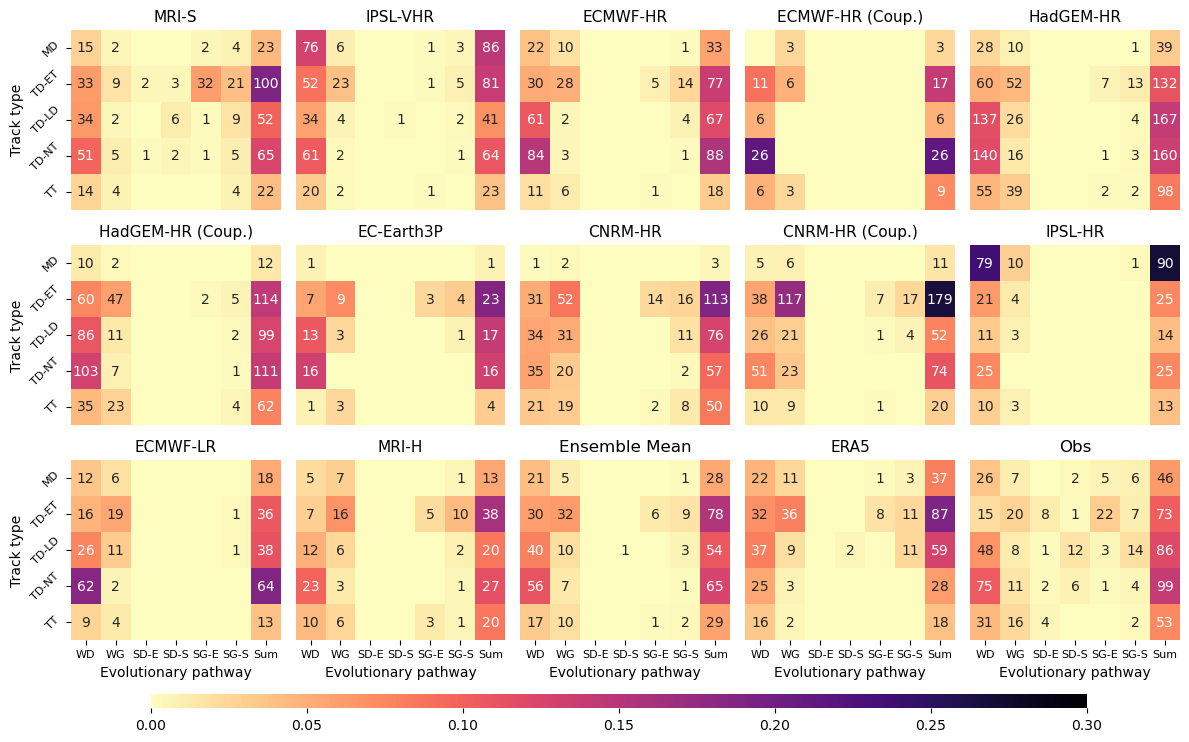

In [ ]:
# Plot all models heatmaps for the NA (Figure 8)
for i, heatmap_data in enumerate(model_heatmaps):
    if i == 12:
        i=i+1
    sub_title=model_title[i]
    ax = fig.add_subplot(3, 5, i + 1)

    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=[name for name, _ in na_begin_end_types],
        columns=[name for name, _ in mslp_rad_types]
    )
    heatmap_df['Sum'] = heatmap_df.sum(axis=1)
    heatmap_norm = heatmap_df.div(heatmap_df.values.sum()).fillna(0)
    annot_data = heatmap_df.map(fmt_nonzero)
    sns.heatmap(
        heatmap_norm,
        annot=annot_data,
        fmt="s",
        cmap="magma_r",
        vmin=0, vmax=0.3,
        ax=ax,
        cbar=False,
    )
    if i in [0, 5, 10]:
        ax.set_ylabel("Track type", fontsize=10)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=45, fontsize=8)
    else:
        ax.set_yticklabels([])
        ax.set_yticks([])
    if i >= 10:
        ax.set_xlabel("Evolutionary pathway", fontsize=10)
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=0)
    else:
        ax.set_xticklabels([])
        ax.set_xticks([])
    ax.set_title(sub_title, fontsize=11)

# Plot ensemble mean
ax = fig.add_subplot(3, 5, 13)
ensemble_mean_heatmap_df = pd.DataFrame(
    ensemble_mean_heatmap,
    index=[name for name, _ in na_begin_end_types],
    columns=[name for name, _ in mslp_rad_types]
)
ensemble_mean_heatmap_df['Sum'] = ensemble_mean_heatmap_df.sum(axis=1)
ensemble_norm = ensemble_mean_heatmap_df.div(ensemble_mean_heatmap_df.values.sum()).fillna(0)
annot_ensemble = ensemble_mean_heatmap_df.map(fmt_nonzero)
sns.heatmap(
    ensemble_norm,
    annot=annot_ensemble,
    fmt="s",
    vmin=0, vmax=0.3,
    cmap="magma_r",
    ax=ax,
    cbar=False,
)
ax.set_xlabel("Evolutionary pathway", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=0)
ax.set_title("Ensemble Mean", fontsize=12)
ax.set_yticklabels([])
ax.set_yticks([])
ax.set_ylabel("")

# Plot observation at last
ax = fig.add_subplot(3, 5, 15)
heatmap_data_na=pd.read_csv("heatmap_data_na.csv")
heatmap_data_na.set_index('Unnamed: 0', inplace=True)
heatmap_data_na['Sum'] = heatmap_data_na.sum(axis=1)
heatmap_norm_na = heatmap_data_na.div(heatmap_data_na.values.sum()).fillna(0)
annot_data_na = heatmap_data_na.map(fmt_nonzero)
cbar_ax = fig.add_axes([0.13, -0.02, 0.78, 0.02])
sns.heatmap(
    heatmap_norm_na,
    annot=annot_data_na,
    fmt="s",
    cmap="magma_r",
    vmin=0, vmax=0.3,
    ax=ax,
    cbar=True, cbar_ax=cbar_ax, cbar_kws={"orientation": "horizontal"}
)
ax.set_xlabel("Evolutionary pathway",fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=0)
ax.set_title("Obs", fontsize=12)
ax.set_yticklabels([])
ax.set_yticks([])
ax.set_ylabel("")
#plt.suptitle("NA (1988-2014): Track type vs Evolutionary pathway heatmaps", fontsize=14,y=0.99)
plt.savefig("../figures/figure8.jpg",dpi=400, bbox_inches='tight')

In [ ]:
# Evolutionary pathway vs Track type heatmaps for all models in the WNP baisn
model_heatmaps = []
model_title = ['MRI-S','IPSL-VHR','ECMWF-HR','ECMWF-HR (Coup.)','HadGEM-HR','HadGEM-HR (Coup.)','EC-Earth3P','CNRM-HR','CNRM-HR (Coup.)','IPSL-HR','ECMWF-LR','MRI-H','Ensemble Mean','ERA5','Obs']
fig = plt.figure(figsize=(12,7), layout="tight")
for i, key in enumerate(dftype.keys()):
    dftrack = dftype[key]

    wp_ms_et_id = dftrack[(dftrack.begin_type == 'MS') & (dftrack.end_type == 'ET') & (dftrack.BASIN == 'WP')].TID.values
    wp_ms_land_id = dftrack[(dftrack.begin_type == 'MS') & (dftrack.end_type == 'LAND') & (dftrack.BASIN == 'WP')].TID.values
    wp_ms_net_id = dftrack[(dftrack.begin_type == 'MS') & (dftrack.end_type == 'Non-ET') & (dftrack.BASIN == 'WP')].TID.values
    wp_nms_et_id = dftrack[(dftrack.begin_type == 'Non-MS') & (dftrack.end_type == 'ET') & (dftrack.BASIN == 'WP')].TID.values
    wp_nms_land_id = dftrack[(dftrack.begin_type == 'Non-MS') & (dftrack.end_type == 'LAND') & (dftrack.BASIN == 'WP')].TID.values
    wp_nms_net_id = dftrack[(dftrack.begin_type == 'Non-MS') & (dftrack.end_type == 'Non-ET') & (dftrack.BASIN == 'WP')].TID.values
    wp_tt_id = dftrack[(dftrack.begin_type == 'TT') & (dftrack.BASIN == 'WP')].TID.values

    wd_id = dftrack[dftrack.dev_type == "WD"].TID.unique()
    wg_id = dftrack[dftrack.dev_type == "WG"].TID.unique()
    sd_e_id = dftrack[dftrack.dev_type == "SD-E"].TID.unique()
    sd_s_id = dftrack[dftrack.dev_type == "SD-S"].TID.unique()
    sg_e_id = dftrack[dftrack.dev_type == "SG-E"].TID.unique()
    sg_s_id = dftrack[dftrack.dev_type == "SG-S"].TID.unique()

    wp_begin_end_types = [
        ("MD-ET", wp_ms_et_id),
        ("TD-ET", wp_nms_et_id),
        ("MD-LD", wp_ms_land_id),
        ("TD-LD", wp_nms_land_id),
        ("MD-NT", wp_ms_net_id),
        ("TD-NT", wp_nms_net_id),
        ("TT", wp_tt_id)
    ]

    mslp_rad_types = [
        ("WD", wd_id),
        ("WG", wg_id),
        ("SD-E", sd_e_id),
        ("SD-S", sd_s_id),
        ("SG-E", sg_e_id),
        ("SG-S", sg_s_id)
    ]

    heatmap_data = pd.DataFrame(0, index=[name for name, _ in wp_begin_end_types], columns=[name for name, _ in mslp_rad_types])

    for begin_end_name, begin_end_ids in wp_begin_end_types:
        for mslp_rad_name, mslp_rad_ids in mslp_rad_types:
            intersect_ids = set(begin_end_ids).intersection(set(mslp_rad_ids))
            heatmap_data.loc[begin_end_name, mslp_rad_name] = len(intersect_ids)

    model_heatmaps.append(heatmap_data.values)

    # Calculate ensemble mean heatmap (across all models)
    if i==11:
        ensemble_mean_heatmap = sum(model_heatmaps) / len(model_heatmaps)
        print(ensemble_mean_heatmap)

# Plot all models
for i, heatmap_data in enumerate(model_heatmaps):
    if i == 12:
        i=i+1
    sub_title=model_title[i]
    ax = fig.add_subplot(3, 5, i + 1)

    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=[name for name, _ in wp_begin_end_types],
        columns=[name for name, _ in mslp_rad_types]
    )
    
    heatmap_df['Sum'] = heatmap_df.sum(axis=1)    
    heatmap_norm = heatmap_df.div(heatmap_df.values.sum()).fillna(0)
    annot_data = heatmap_df.map(fmt_nonzero)
    sns.heatmap(
        heatmap_norm,
        annot=annot_data,
        fmt="s",
        cmap="magma_r",
        ax=ax,
        vmin=0,vmax=0.3,
        cbar=False,
    )
    if i in [0, 5, 10]:
        ax.set_ylabel("Track type", fontsize=10)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=45, fontsize=8)
    else:
        ax.set_yticklabels([])
        ax.set_yticks([])
    if i >= 10:
        ax.set_xlabel("Evolutionary pathway", fontsize=10)
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=0)
    else:
        ax.set_xticklabels([])
        ax.set_xticks([])
    ax.set_title(sub_title, fontsize=11)


[[ 5.66666667  7.5         0.08333333  0.41666667  1.91666667  5.        ]
 [23.5        28.33333333  0.41666667  0.25        5.66666667 19.5       ]
 [17.33333333 11.5         0.          0.66666667  0.08333333  7.75      ]
 [24.08333333 16.66666667  0.          0.66666667  0.25       10.66666667]
 [20.41666667  9.5         0.08333333  0.          0.08333333  2.        ]
 [79.         22.91666667  0.          0.83333333  0.75        6.        ]
 [ 6.33333333  2.08333333  0.          0.          0.08333333  1.        ]]


/global/homes/y/ykh5116/.conda/envs/easy/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/tmp/ipykernel_542230/602519192.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("../figures/size/figure9_2.jpg",dpi=400, bbox_inches='tight')
/tmp/ipykernel_542230/602519192.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("../figures/size/figure9_2.jpg",dpi=400, bbox_inches='tight')
/global/homes/y/ykh5116/.conda/envs/easy/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


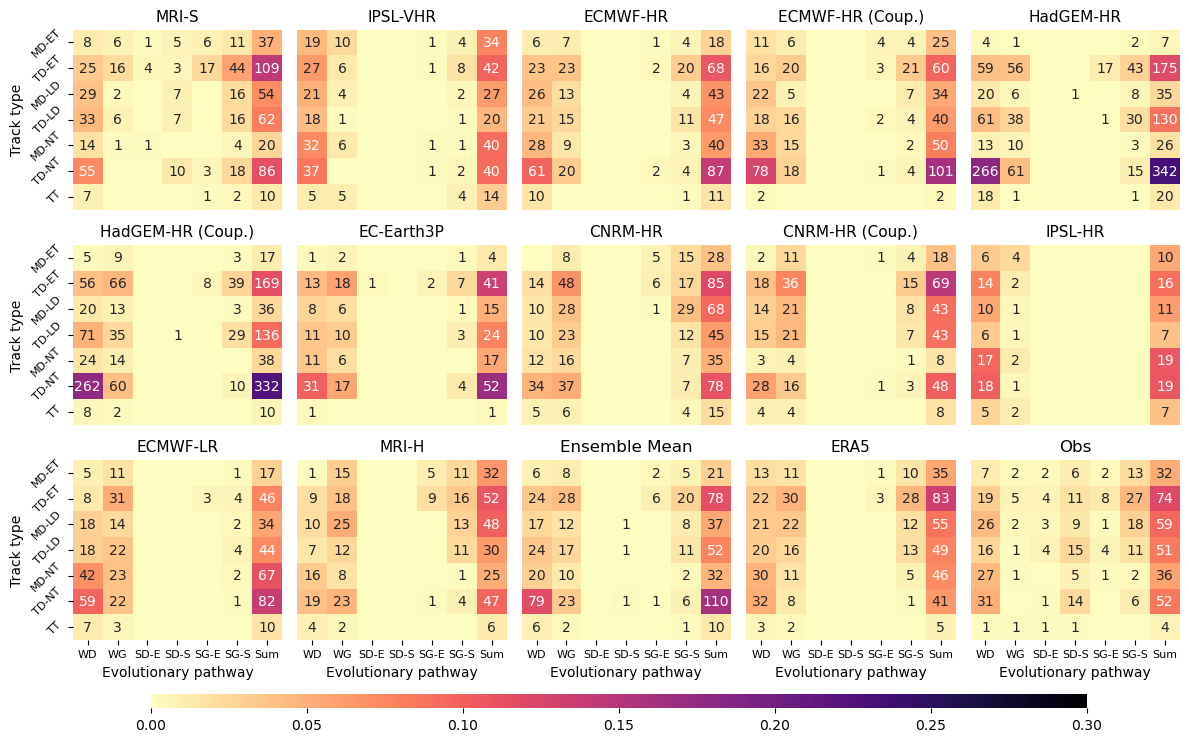

In [ ]:
# Plot all models heatmaps for the WNP (Figure 9)
ax = fig.add_subplot(3, 5, 13)
ensemble_mean_heatmap_df = pd.DataFrame(
    ensemble_mean_heatmap,
    index=[name for name, _ in wp_begin_end_types],
    columns=[name for name, _ in mslp_rad_types]
)
ensemble_mean_heatmap_df['Sum'] = ensemble_mean_heatmap_df.sum(axis=1)
ensemble_norm = ensemble_mean_heatmap_df.div(ensemble_mean_heatmap_df.values.sum()).fillna(0)
annot_ensemble = ensemble_mean_heatmap_df.map(fmt_nonzero)
sns.heatmap(
    ensemble_norm,
    annot=annot_ensemble,
    fmt="s",
    cmap="magma_r",
    ax=ax,
    vmin=0,vmax=0.3,
    cbar=False,
)
ax.set_xlabel("Evolutionary pathway", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=0)
ax.set_title("Ensemble Mean", fontsize=12)
ax.set_yticklabels([])
ax.set_yticks([])
ax.set_ylabel("")

# Plot observation at last
ax = fig.add_subplot(3, 5, 15)
heatmap_data_wp=pd.read_csv("heatmap_data_wp.csv")
heatmap_data_wp.set_index('Unnamed: 0', inplace=True)
heatmap_data_wp['Sum'] = heatmap_data_wp.sum(axis=1)
heatmap_norm_wp = heatmap_data_wp.div(heatmap_data_wp.values.sum()).fillna(0)
annot_data_wp = heatmap_data_wp.map(fmt_nonzero)
cbar_ax = fig.add_axes([0.13, -0.02, 0.78, 0.02])
sns.heatmap(
    heatmap_norm_wp,
    annot=annot_data_wp,
    fmt="s",
    cmap="magma_r",
    ax=ax,
    vmin=0,vmax=0.3,
    cbar=True, cbar_ax=cbar_ax, cbar_kws={"orientation": "horizontal"}
)
ax.set_xlabel("Evolutionary pathway",fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=0)
ax.set_title("Obs", fontsize=12)
ax.set_yticklabels([])
ax.set_yticks([])
ax.set_ylabel("")
#plt.suptitle("WNP (2002-2014): Track type vs Evolution path heatmaps", fontsize=14,y=0.99)
plt.savefig("../figures/figure9.jpg",dpi=400, bbox_inches='tight')

In [17]:
# Load Nino3.4 index data and identify El Niño and La Niña years
nino34ind=pd.read_csv('../nino34_anom.csv',index_col='YEAR')
nino34ind=nino34ind[['MAY','JUN','JUL','AUG','SEP','OCT','NOV']]
ninoseason_mean = nino34ind.mean(axis=1)
ninoseason_mean=ninoseason_mean.loc[1988:2023].to_numpy()

year_range=np.arange(1988,2024,1)
lanina_year=year_range[ninoseason_mean<=-0.4]
elnino_year=year_range[ninoseason_mean>=0.4]

# Load observation heatmap data for El Niño and La Niña years
heatmap_data_na_la=pd.read_csv("heatmap_data_na_lanina_new.csv")
heatmap_data_wp_la=pd.read_csv("heatmap_data_wp_lanina_new.csv")
heatmap_data_na_el=pd.read_csv("heatmap_data_na_elnino_new.csv")
heatmap_data_wp_el=pd.read_csv("heatmap_data_wp_elnino_new.csv")
# heatmap_data_na.set_index('Unnamed: 0', inplace=True)
# heatmap_data_wp.set_index('Unnamed: 0', inplace=True)
heatmap_data_na_la.set_index('Unnamed: 0', inplace=True)
heatmap_data_wp_la.set_index('Unnamed: 0', inplace=True)
heatmap_data_na_el.set_index('Unnamed: 0', inplace=True)
heatmap_data_wp_el.set_index('Unnamed: 0', inplace=True)

In [18]:
# Help function to format non-zero values
def fmt_nonzero2(x):
    if x=="":
        return ""
    else:
        x=float(x)
        return "" if abs(x) < 0.01 else f"{round(x*100)}%"

In [19]:
from scipy.stats import norm
from scipy.stats import ttest_1samp

def prepare_annotations_ens(heatmaps_diff_lst):
    flat_annots = []
    for i in range(len(heatmaps_diff_lst[0].index)):
        for j in range(len(heatmaps_diff_lst[0].columns)):

            diff = np.array([df.iloc[i, j] for df in heatmaps_diff_lst])
            diff_mean = diff.mean()
                
            # Significance
            t_stat, p_value = ttest_1samp(diff, 0)

            # Agreement
            mean_diff = diff.mean()

            if mean_diff > 0:
                agreement = np.sum(diff > 0) / len(diff)
            else:
                agreement = np.sum(diff < 0) / len(diff)
            
            robust = (p_value < 0.1) and (agreement >= 0.75)
            flat_annots.append(f"{diff_mean * 100:.0f}%" if robust else "")

    return flat_annots


def prepare_annotations(heatmap_data_el, heatmap_data_la, heatmap_norm_el, heatmap_norm_la):

    flat_annots = []
    n_el = int(heatmap_data_el.loc["Sum", "Sum"])
    n_la = int(heatmap_data_la.loc["Sum", "Sum"])

    for r in heatmap_norm_el.index:
        for c in heatmap_norm_el.columns:
            a = heatmap_data_el.loc[r, c]
            b = heatmap_data_la.loc[r, c]

            if n_el > 0 and n_la > 0:
                pooled = (a + b) / (n_el + n_la)
                se = np.sqrt(pooled * (1 - pooled) * (1.0 / n_el + 1.0 / n_la))
                pval = 2 * (1 - norm.cdf(abs((a / n_el - b / n_la) / se))) if se > 0 else 1.0
            else:
                pval = 1.0

            diff = heatmap_norm_el.loc[r, c] - heatmap_norm_la.loc[r, c]
            flat_annots.append(f"{diff * 100:.0f}%" if (pval <= 0.1 and diff != 0) else "")

    return flat_annots

# reorganize flat_annots into a 2D list matching the heatmap shape
def reshape_annotations(flat_annots, heatmap_shape):
    return [flat_annots[i:i + heatmap_shape[1]] for i in range(0, len(flat_annots), heatmap_shape[1])]

In [ ]:
# Calculate and store ENSO heatmaps for the NA for each model

keys_order = ['mris','ipslvhr','echrm1','hadgem','ecearth3p','cnrm','ipslhr','eclrm1','mrih','era5']
dftype2 = {k: dftype[k] for k in keys_order if k in dftype}
model_title = ['MRI-S','IPSL-VHR','ECMWF-HR','HadGEM-HR','EC-Earth3P','CNRM-HR','IPSL-HR','ECMWF-LR','MRI-H','ERA5','Ensemble Mean','Obs']
heatmaps_diff_lst = []
flat_annots_lst = []
heatmap_data_la_lst = []
heatmap_data_el_lst = []
for i, key in enumerate(dftype2.keys()):
    dftrack = dftype2[key]
    wd_id = dftrack[dftrack.dev_type == "WD"].TID.unique()
    wg_id = dftrack[dftrack.dev_type == "WG"].TID.unique()
    sd_id = dftrack[dftrack.dev_type.str.contains('SD')].TID.unique()
    sg_id = dftrack[dftrack.dev_type.str.contains('SG')].TID.unique()

    mslp_rad_types = [
        ("WD", wd_id),
        ("WG", wg_id),
        ("SD", sd_id),
        ("SG", sg_id),
        ("Sum", np.unique(np.concatenate([wd_id, wg_id, sd_id, sg_id])))
    ]

    # El Nino
    dftrack_el = dftrack[dftrack.year.isin(elnino_year)].reset_index(drop=True)
    el_na_ms_id = dftrack_el[(dftrack_el.begin_type == 'MS') & (dftrack_el.BASIN == 'NA')].TID.values
    el_na_nms_et_id = dftrack_el[(dftrack_el.end_type == 'ET') & (dftrack_el.begin_type == 'Non-MS') & (dftrack_el.BASIN == 'NA')].TID.values
    el_na_nms_land_id = dftrack_el[(dftrack_el.end_type == 'LAND') & (dftrack_el.begin_type == 'Non-MS') & (dftrack_el.BASIN == 'NA')].TID.values
    el_na_nms_net_id = dftrack_el[(dftrack_el.end_type == 'Non-ET') & (dftrack_el.begin_type == 'Non-MS') & (dftrack_el.BASIN == 'NA')].TID.values
    el_na_tt_id = dftrack_el[(dftrack_el.begin_type == 'TT') & (dftrack_el.BASIN == 'NA')].TID.values

    el_na_begin_end_types = [
        ("MD", el_na_ms_id),
        ("TD-ET", el_na_nms_et_id),
        ("TD-LD", el_na_nms_land_id),
        ("TD-NT", el_na_nms_net_id),
        ("TT", el_na_tt_id),
        ("Sum", dftrack_el[dftrack_el.BASIN == 'NA'].TID.values)
    ]

    # La Nina
    dftrack_la = dftrack[dftrack.year.isin(lanina_year)].reset_index(drop=True)
    la_na_ms_id = dftrack_la[(dftrack_la.begin_type == 'MS') & (dftrack_la.BASIN == 'NA')].TID.values
    la_na_nms_et_id = dftrack_la[(dftrack_la.end_type == 'ET') & (dftrack_la.begin_type == 'Non-MS') & (dftrack_la.BASIN == 'NA')].TID.values
    la_na_nms_land_id = dftrack_la[(dftrack_la.end_type == 'LAND') & (dftrack_la.begin_type == 'Non-MS') & (dftrack_la.BASIN == 'NA')].TID.values
    la_na_nms_net_id = dftrack_la[(dftrack_la.end_type == 'Non-ET') & (dftrack_la.begin_type == 'Non-MS') & (dftrack_la.BASIN == 'NA')].TID.values
    la_na_tt_id = dftrack_la[(dftrack_la.begin_type == 'TT') & (dftrack_la.BASIN == 'NA')].TID.values

    la_na_begin_end_types = [
        ("MD", la_na_ms_id),
        ("TD-ET", la_na_nms_et_id),
        ("TD-LD", la_na_nms_land_id),
        ("TD-NT", la_na_nms_net_id),
        ("TT", la_na_tt_id),
        ("Sum", dftrack_la[dftrack_la.BASIN == 'NA'].TID.values)
    ]

    heatmap_data_el = pd.DataFrame(0, index=[name for name, _ in el_na_begin_end_types], columns=[name for name, _ in mslp_rad_types])
    for begin_end_name, begin_end_ids in el_na_begin_end_types:
        for mslp_rad_name, mslp_rad_ids in mslp_rad_types:
            intersect_ids = set(begin_end_ids).intersection(set(mslp_rad_ids))
            heatmap_data_el.loc[begin_end_name, mslp_rad_name] = len(intersect_ids)
    heatmap_norm_el = heatmap_data_el.div(heatmap_data_el.iloc[-1, -1]).fillna(0)

    heatmap_data_la = pd.DataFrame(0, index=[name for name, _ in la_na_begin_end_types], columns=[name for name, _ in mslp_rad_types])
    for begin_end_name, begin_end_ids in la_na_begin_end_types:
        for mslp_rad_name, mslp_rad_ids in mslp_rad_types:
            intersect_ids = set(begin_end_ids).intersection(set(mslp_rad_ids))
            heatmap_data_la.loc[begin_end_name, mslp_rad_name] = len(intersect_ids)
    heatmap_norm_la = heatmap_data_la.div(heatmap_data_la.iloc[-1, -1]).fillna(0)

    heatmap_diff = heatmap_norm_el.reindex(index=heatmap_norm_la.index, columns=heatmap_norm_la.columns, fill_value=0) - heatmap_norm_la
    heatmaps_diff_lst.append(heatmap_diff)
    flat_annots = prepare_annotations(heatmap_data_el, heatmap_data_la, heatmap_norm_el, heatmap_norm_la)
    flat_annots_lst.append(flat_annots)
    heatmap_data_la_lst.append(heatmap_data_la)
    heatmap_data_el_lst.append(heatmap_data_el)

# Calculate ensemble mean heatmap
if i==9:
    # heatmap_data_el = sum(heatmap_data_el_lst)
    # heatmap_data_la = sum(heatmap_data_la_lst)
    # heatmap_norm_el = heatmap_data_el.div(heatmap_data_el.iloc[-1, -1]).fillna(0)
    # heatmap_norm_la = heatmap_data_la.div(heatmap_data_la.iloc[-1, -1]).fillna(0)
    #ensemble_mean_diff = heatmap_norm_el.reindex(index=heatmap_norm_la.index, columns=heatmap_norm_la.columns, fill_value=0) - heatmap_norm_la
    ensemble_mean_diff = sum(heatmaps_diff_lst) / len(heatmaps_diff_lst)
    flat_annots_ensemble = prepare_annotations_ens(heatmaps_diff_lst)

# Plotting NA 
fig = plt.figure(figsize=(14, 5), layout="tight")
for i, heatmap_diff in enumerate(heatmaps_diff_lst):
    annots=flat_annots_lst[i]
    sub_title=model_title[i]
    if i == 9:
        i=i+1
        sub_title=model_title[i-1]
    ax = fig.add_subplot(2, 6, i + 1)
    #_flat_annots = []
    # build annot_data from flat_annots (handles list of arrays/dataframes)
    # annot_item = flat_annots[i] if isinstance(flat_annots, (list, tuple)) else flat_annots
    # if isinstance(annot_item, pd.DataFrame):
    #     annot_data = annot_item.applymap(fmt_nonzero2)
    # else:
    #     annot_df = pd.DataFrame(annot_item, index=heatmap_diff.index, columns=heatmap_diff.columns)

    annot_data=reshape_annotations(annots, heatmap_diff.shape)
    # print(annot_data)
    sns.heatmap(
        heatmap_diff,
        annot=annot_data,
        fmt="s",
        cmap="coolwarm",
        vmin=-0.25, vmax=0.25,
        ax=ax,
        cbar=False,
    )
    if i in [0, 6]:
        ax.set_ylabel("Track type", fontsize=11)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=45, fontsize=10)
    else:
        ax.set_yticklabels([])
        ax.set_yticks([])
    if i >= 6:
        #ax.set_xlabel("Development type", fontsize=10)
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, rotation=0)
    else:
        ax.set_xticklabels([])
        ax.set_xticks([])
    ax.set_title(f"NA: {sub_title}", fontsize=12)

# Plot ensemble mean
ax = fig.add_subplot(2, 6, 10)
annot_data_ens=reshape_annotations(flat_annots_ensemble, ensemble_mean_diff.shape)
sns.heatmap(
    ensemble_mean_diff,
    annot=annot_data_ens,
    fmt="s",
    cmap="coolwarm",
    vmin=-0.25, vmax=0.25,
    ax=ax,
    cbar=False,
)
#ax.set_xlabel("Development type", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, rotation=0)
ax.set_title("NA: Ensemble Mean", fontsize=13)
ax.set_yticklabels([])
ax.set_yticks([])
ax.set_ylabel("")

# plot observations
ax = fig.add_subplot(2, 6, 12)
heatmap_norm_na_el = heatmap_data_na_el.div(heatmap_data_na_el.iloc[-1, -1]).fillna(0)
heatmap_norm_na_la = heatmap_data_na_la.div(heatmap_data_na_la.iloc[-1, -1]).fillna(0)
heatmap_diff_obs_na = heatmap_norm_na_el.reindex(index=heatmap_norm_na_la.index, columns=heatmap_norm_na_la.columns, fill_value=0) - heatmap_norm_na_la
flat_annots_na = prepare_annotations(heatmap_data_na_el, heatmap_data_na_la, heatmap_norm_na_el, heatmap_norm_na_la)
annot_data_na=reshape_annotations(flat_annots_na, heatmap_diff_obs_na.shape)
sns.heatmap(
    heatmap_diff_obs_na,
    annot=annot_data_na,
    fmt="s",
    cmap="coolwarm",
    ax=ax,
    vmin=-0.25,vmax=0.25,
    cbar=False,
)
#ax.set_xlabel("Development type",fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, rotation=0)
ax.set_title("NA: Obs", fontsize=13)
ax.set_yticklabels([])
ax.set_yticks([])
ax.set_ylabel("")
plt.savefig("../figures/figure10_na_new.png", dpi=300)


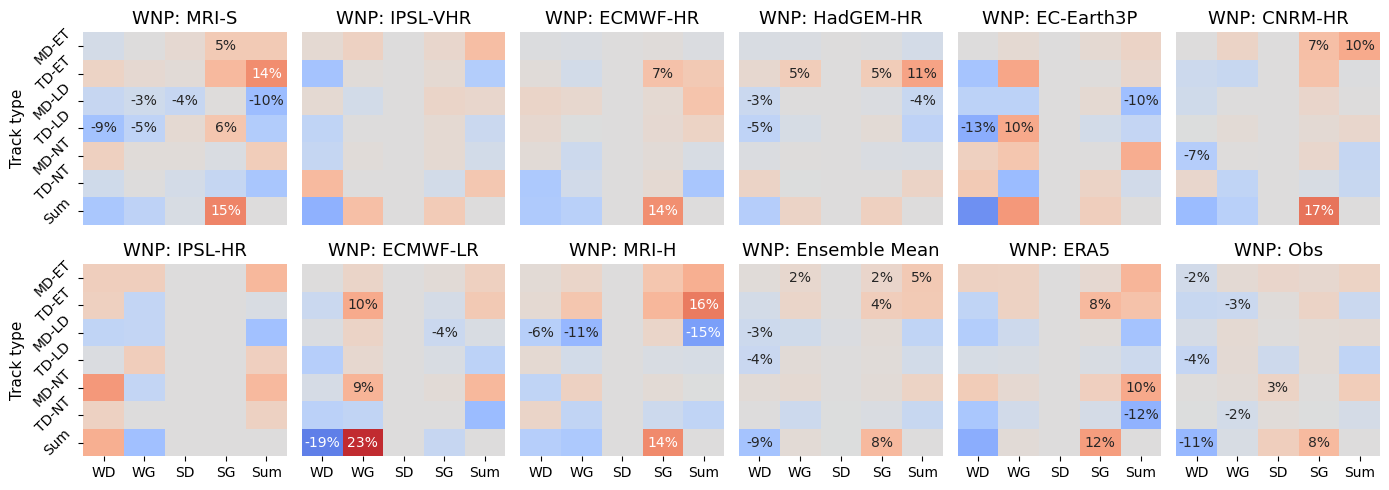

In [20]:
# Calculate and store ENSO heatmaps for the NA for each model

keys_order = ['mris','ipslvhr','echrm1','hadgem','ecearth3p','cnrm','ipslhr','eclrm1','mrih','era5']
dftype2 = {k: dftype[k] for k in keys_order if k in dftype}
model_title = ['MRI-S','IPSL-VHR','ECMWF-HR','HadGEM-HR','EC-Earth3P','CNRM-HR','IPSL-HR','ECMWF-LR','MRI-H','ERA5','Ensemble Mean','Obs']
heatmaps_diff_lst = []
flat_annots_lst = []
heatmap_data_la_lst = []
heatmap_data_el_lst = []
for i, key in enumerate(dftype2.keys()):
    dftrack = dftype2[key]
    wd_id = dftrack[dftrack.dev_type == "WD"].TID.unique()
    wg_id = dftrack[dftrack.dev_type == "WG"].TID.unique()
    sd_id = dftrack[dftrack.dev_type.str.contains('SD')].TID.unique()
    sg_id = dftrack[dftrack.dev_type.str.contains('SG')].TID.unique()

    mslp_rad_types = [
        ("WD", wd_id),
        ("WG", wg_id),
        ("SD", sd_id),
        ("SG", sg_id),
        ("Sum", np.unique(np.concatenate([wd_id, wg_id, sd_id, sg_id])))
    ]

    # El Nino
    dftrack_el = dftrack[dftrack.year.isin(elnino_year)].reset_index(drop=True)
    el_wp_ms_et_id=dftrack_el[(dftrack_el.end_type=='ET') & (dftrack_el.begin_type=='MS') & (dftrack_el.BASIN=='WP')].TID.values
    el_wp_ms_land_id=dftrack_el[(dftrack_el.end_type=='LAND') & (dftrack_el.begin_type=='MS') & (dftrack_el.BASIN=='WP')].TID.values
    el_wp_ms_net_id=dftrack_el[(dftrack_el.end_type=='Non-ET') & (dftrack_el.begin_type=='MS') & (dftrack_el.BASIN=='WP')].TID.values
    el_wp_nms_et_id=dftrack_el[(dftrack_el.end_type=='ET') & (dftrack_el.begin_type=='Non-MS') & (dftrack_el.BASIN=='WP')].TID.values
    el_wp_nms_land_id=dftrack_el[(dftrack_el.end_type=='LAND') & (dftrack_el.begin_type=='Non-MS') & (dftrack_el.BASIN=='WP')].TID.values
    el_wp_nms_net_id=dftrack_el[(dftrack_el.end_type=='Non-ET') & (dftrack_el.begin_type=='Non-MS') & (dftrack_el.BASIN=='WP')].TID.values
    el_wp_id=dftrack_el[(dftrack_el.BASIN=='WP')].TID.values

    el_wp_begin_end_types = [
        ("MD-ET", el_wp_ms_et_id),
        ("TD-ET", el_wp_nms_et_id),
        ("MD-LD", el_wp_ms_land_id),
        ("TD-LD", el_wp_nms_land_id),
        ("MD-NT", el_wp_ms_net_id),
        ("TD-NT", el_wp_nms_net_id),
        ("Sum", el_wp_id)
    ]
    

    # La Nina
    dftrack_la = dftrack[dftrack.year.isin(lanina_year)].reset_index(drop=True)
    la_wp_ms_et_id=dftrack_la[(dftrack_la.end_type=='ET') & (dftrack_la.begin_type=='MS') & (dftrack_la.BASIN=='WP')].TID.values
    la_wp_ms_land_id=dftrack_la[(dftrack_la.end_type=='LAND') & (dftrack_la.begin_type=='MS') & (dftrack_la.BASIN=='WP')].TID.values
    la_wp_ms_net_id=dftrack_la[(dftrack_la.end_type=='Non-ET') & (dftrack_la.begin_type=='MS') & (dftrack_la.BASIN=='WP')].TID.values
    la_wp_nms_et_id=dftrack_la[(dftrack_la.end_type=='ET') & (dftrack_la.begin_type=='Non-MS') & (dftrack_la.BASIN=='WP')].TID.values
    la_wp_nms_land_id=dftrack_la[(dftrack_la.end_type=='LAND') & (dftrack_la.begin_type=='Non-MS') & (dftrack_la.BASIN=='WP')].TID.values
    la_wp_nms_net_id=dftrack_la[(dftrack_la.end_type=='Non-ET') & (dftrack_la.begin_type=='Non-MS') & (dftrack_la.BASIN=='WP')].TID.values
    la_wp_id=dftrack_la[(dftrack_la.BASIN=='WP')].TID.values

    la_wp_begin_end_types = [
        ("MD-ET", la_wp_ms_et_id),
        ("TD-ET", la_wp_nms_et_id),
        ("MD-LD", la_wp_ms_land_id),
        ("TD-LD", la_wp_nms_land_id),
        ("MD-NT", la_wp_ms_net_id),
        ("TD-NT", la_wp_nms_net_id),
        ("Sum", la_wp_id)
    ]

    heatmap_data_el = pd.DataFrame(0, index=[name for name, _ in el_wp_begin_end_types], columns=[name for name, _ in mslp_rad_types])
    for begin_end_name, begin_end_ids in el_wp_begin_end_types:
        for mslp_rad_name, mslp_rad_ids in mslp_rad_types:
            intersect_ids = set(begin_end_ids).intersection(set(mslp_rad_ids))
            heatmap_data_el.loc[begin_end_name, mslp_rad_name] = len(intersect_ids)
    heatmap_norm_el = heatmap_data_el.div(heatmap_data_el.iloc[-1, -1]).fillna(0)

    heatmap_data_la = pd.DataFrame(0, index=[name for name, _ in la_wp_begin_end_types], columns=[name for name, _ in mslp_rad_types])
    for begin_end_name, begin_end_ids in la_wp_begin_end_types:
        for mslp_rad_name, mslp_rad_ids in mslp_rad_types:
            intersect_ids = set(begin_end_ids).intersection(set(mslp_rad_ids))
            heatmap_data_la.loc[begin_end_name, mslp_rad_name] = len(intersect_ids)
    heatmap_norm_la = heatmap_data_la.div(heatmap_data_la.iloc[-1, -1]).fillna(0)

    heatmap_diff = heatmap_norm_el.reindex(index=heatmap_norm_la.index, columns=heatmap_norm_la.columns, fill_value=0) - heatmap_norm_la
    heatmaps_diff_lst.append(heatmap_diff)
    flat_annots = prepare_annotations(heatmap_data_el, heatmap_data_la, heatmap_norm_el, heatmap_norm_la)
    flat_annots_lst.append(flat_annots)
    heatmap_data_la_lst.append(heatmap_data_la)
    heatmap_data_el_lst.append(heatmap_data_el)

# Calculate ensemble mean heatmap
if i==9:
    # heatmap_data_el = sum(heatmap_data_el_lst)
    # heatmap_data_la = sum(heatmap_data_la_lst)
    # heatmap_norm_el = heatmap_data_el.div(heatmap_data_el.iloc[-1, -1]).fillna(0)
    # heatmap_norm_la = heatmap_data_la.div(heatmap_data_la.iloc[-1, -1]).fillna(0)
    # ensemble_mean_diff = heatmap_norm_el.reindex(index=heatmap_norm_la.index, columns=heatmap_norm_la.columns, fill_value=0) - heatmap_norm_la
    # flat_annots_ensemble = prepare_annotations(heatmap_data_el, heatmap_data_la, heatmap_norm_el, heatmap_norm_la)
    ensemble_mean_diff = sum(heatmaps_diff_lst) / len(heatmaps_diff_lst)
    flat_annots_ensemble = prepare_annotations_ens(heatmaps_diff_lst)

# Plotting WP 
fig = plt.figure(figsize=(14, 5), layout="tight")
for i, heatmap_diff in enumerate(heatmaps_diff_lst):
    annots=flat_annots_lst[i]
    sub_title=model_title[i]
    if i == 9:
        i=i+1
        sub_title=model_title[i-1]
    ax = fig.add_subplot(2, 6, i + 1)
    #_flat_annots = []
    # build annot_data from flat_annots (handles list of arrays/dataframes)
    # annot_item = flat_annots[i] if isinstance(flat_annots, (list, tuple)) else flat_annots
    # if isinstance(annot_item, pd.DataFrame):
    #     annot_data = annot_item.applymap(fmt_nonzero2)
    # else:
    #     annot_df = pd.DataFrame(annot_item, index=heatmap_diff.index, columns=heatmap_diff.columns)

    annot_data=reshape_annotations(annots, heatmap_diff.shape)
    # print(annot_data)
    sns.heatmap(
        heatmap_diff,
        annot=annot_data,
        fmt="s",
        cmap="coolwarm",
        vmin=-0.25, vmax=0.25,
        ax=ax,
        cbar=False,
    )
    if i in [0, 6]:
        ax.set_ylabel("Track type", fontsize=11)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=45, fontsize=10)
    else:
        ax.set_yticklabels([])
        ax.set_yticks([])
    if i >= 6:
        # ax.set_xlabel("Evolutionary Pathway", fontsize=11)
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, rotation=0)
    else:
        ax.set_xticklabels([])
        ax.set_xticks([])
    ax.set_title(f"WNP: {sub_title}", fontsize=13)

# Plot ensemble mean
ax = fig.add_subplot(2, 6, 10)
annot_data_ens=reshape_annotations(flat_annots_ensemble, ensemble_mean_diff.shape)
sns.heatmap(
    ensemble_mean_diff,
    annot=annot_data_ens,
    fmt="s",
    cmap="coolwarm",
    vmin=-0.25, vmax=0.25,
    ax=ax,
    cbar=False,
)
#ax.set_xlabel("Development type", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, rotation=0)
ax.set_title("WNP: Ensemble Mean", fontsize=13)
ax.set_yticklabels([])
ax.set_yticks([])
ax.set_ylabel("")

# plot observations
ax = fig.add_subplot(2, 6, 12)
heatmap_norm_wp_el = heatmap_data_wp_el.div(heatmap_data_wp_el.iloc[-1, -1]).fillna(0)
heatmap_norm_wp_la = heatmap_data_wp_la.div(heatmap_data_wp_la.iloc[-1, -1]).fillna(0)
heatmap_diff_obs_wp = heatmap_norm_wp_el.reindex(index=heatmap_norm_wp_la.index, columns=heatmap_norm_wp_la.columns, fill_value=0) - heatmap_norm_wp_la
flat_annots_wp = prepare_annotations(heatmap_data_wp_el, heatmap_data_wp_la, heatmap_norm_wp_el, heatmap_norm_wp_la)
annot_data_wp=reshape_annotations(flat_annots_wp, heatmap_diff_obs_wp.shape)
sns.heatmap(
    heatmap_diff_obs_wp,
    annot=annot_data_wp,
    fmt="s",
    cmap="coolwarm",
    ax=ax,
    vmin=-0.25,vmax=0.25,
    cbar=False,
)
#ax.set_xlabel("Development type",fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, rotation=0)
ax.set_title("WNP: Obs", fontsize=13)
ax.set_yticklabels([])
ax.set_yticks([])
ax.set_ylabel("")
plt.savefig("../figures/figure10_wp_new.png", dpi=300)


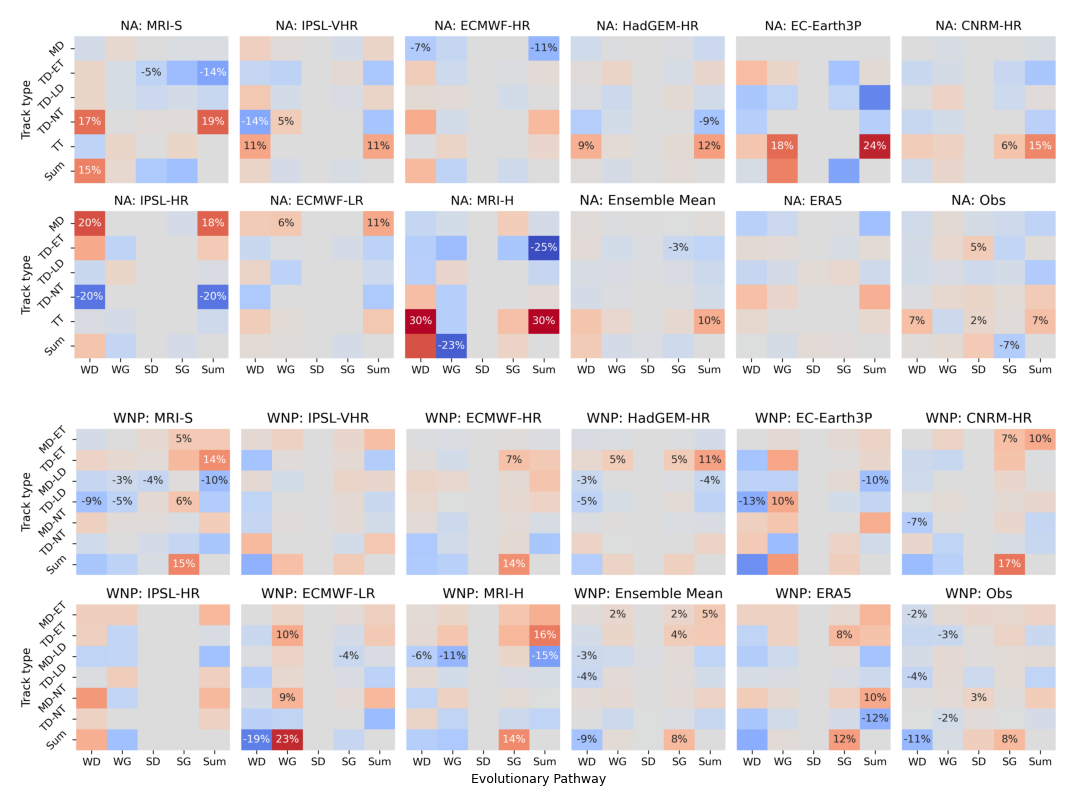

In [21]:
# Combine the NA and WNP ENSO heatmap figures into one figure (Figure 10)
img1 = mpimg.imread("../figures/figure10_na_new.png")
img2 = mpimg.imread("../figures/figure10_wp_new.png")

fig, axes = plt.subplots(2, 1, figsize=(12,8),layout="tight")

axes[0].imshow(img1)
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].axis("off")
# Add a x-label to the figure at the bottom
fig.text(0.5, 0.02, 'Evolutionary Pathway', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("../figures/figure10_new.jpg", dpi=300, bbox_inches='tight')